# Paclitaxel Multi-omics Figures

This notebook generates manuscript-ready figure panels for the paclitaxel multi-omics classification case study. It reads the saved outputs from `2-ML.ipynb` and does not rerun model training.

## Imports and Paths

In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
from scipy.stats import mannwhitneyu
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    auc,
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)

warnings.filterwarnings("ignore")

from pipeline_utils import make_case4_paths

paths = make_case4_paths()
DATA_DIR = paths["proc"]
RESULTS_DIR = paths["results"]
FIGURE_DIR = paths["figures"]

sys.path.append(str(paths["project"] / "4_paclitaxel"))
from feature_sets import (
    add_binary_response,
    load_pax_genes,
    load_nest_genes,
    split_x_class_y,
    select_features_by_omics,
)

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

RANDOM_STATE = 42
RESPONSE_ORDER = ["Resistant", "Sensitive"]
MRECIST_ORDER = ["PD", "SD", "PR", "CR"]
PALETTE_BINARY = {"Resistant": "#4C78A8", "Sensitive": "#E45756"}
PALETTE_MRECIST = {"PD": "#4C78A8", "SD": "#72B7B2", "PR": "#F58518", "CR": "#E45756"}

print("Project root:", paths["project"])
print("Figure dir:", FIGURE_DIR)

Project root: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study
Figure dir: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/4_paclitaxel/figures


## Load Data and Results

In [2]:
metadata_df = pd.read_csv(DATA_DIR / "metadata.csv", index_col=0)
metadata_df = add_binary_response(metadata_df)

# Loaded for the RNA feature-importance panel (Figure 5) -- same fixed
# slope.treatment < 0 cutoff as notebook 2, applied identically regardless of
# subset since it's a constant, not a per-subset median.
rna_df = add_binary_response(pd.read_csv(DATA_DIR / "rna_logtpm.csv", index_col=0))
pax_genes = load_pax_genes()
nest_genes = load_nest_genes()

single_results_df = pd.read_csv(RESULTS_DIR / "single_omics_classification_cv_results.csv")
single_predictions_df = pd.read_csv(RESULTS_DIR / "single_omics_classification_cv_predictions.csv")
early_results_df = pd.read_csv(RESULTS_DIR / "early_fusion_classification_cv_results.csv")
early_predictions_df = pd.read_csv(RESULTS_DIR / "early_fusion_classification_cv_predictions.csv")
late_results_df = pd.read_csv(RESULTS_DIR / "late_fusion_classification_cv_results.csv")
late_predictions_df = pd.read_csv(RESULTS_DIR / "late_fusion_classification_cv_predictions.csv")
summary_df = pd.read_csv(RESULTS_DIR / "classification_model_summary.csv")
response_qc_df = pd.read_csv(RESULTS_DIR / "response_metric_qc.csv")

all_results_df = pd.concat([single_results_df, early_results_df, late_results_df], ignore_index=True)
all_predictions_df = pd.concat([single_predictions_df, early_predictions_df, late_predictions_df], ignore_index=True)

print("metadata", metadata_df.shape)
print("rna_all", rna_df.shape)
print("all_results", all_results_df.shape)
print("all_predictions", all_predictions_df.shape)
summary_df.head(10)

metadata (80, 5)
rna_all (67, 14025)
all_results (250, 31)
all_predictions (3100, 14)


,analysis,omics,model,auroc_mean,auroc_sd,auroc_ci_lo,auroc_ci_hi,auroc_p_vs_chance,auprc_mean,auprc_sd,balanced_accuracy_mean,balanced_accuracy_sd,f1_mean,sensitivity_mean,specificity_mean,n_features_mean,n_folds,auroc_p_adj_fdr
0,single_omics,rna_paired,random_forest,0.711238,0.096553,0.671383,0.751093,8.282546e-11,0.770809,0.102380,0.578000,0.083752,0.713891,0.840000,0.316000,2045.60,25,8.282546e-10
1,early_fusion,rna_cnv_mutation,random_forest,0.704524,0.105817,0.660845,0.748203,9.540463e-10,0.761744,0.107318,0.605690,0.097486,0.749263,0.900714,0.310667,2969.84,25,4.770232e-09
2,single_omics,rna_paired,logistic_l2,0.651619,0.106550,0.607637,0.695601,2.355628e-07,0.743039,0.096384,0.632738,0.088910,0.672608,0.652143,0.613333,2045.60,25,7.852092e-07
3,late_fusion_stacking,rna_cnv_mutation,stack_random_forest,0.641429,0.154447,0.577676,0.705181,1.212810e-04,0.734195,0.120520,0.598310,0.105489,0.629287,0.639286,0.557333,3.00,25,3.032026e-04
4,late_fusion_stacking,rna_cnv_mutation,stack_logistic_l2,0.613857,0.127160,0.561368,0.666346,1.570649e-04,0.724614,0.109139,0.584405,0.130797,0.614575,0.582143,0.586667,3.00,25,3.141299e-04
5,early_fusion,rna_cnv_mutation,logistic_l2,0.609190,0.161974,0.542331,0.676050,2.533958e-03,0.703508,0.121158,0.644143,0.124193,0.695339,0.704286,0.584000,2969.84,25,3.619940e-03
6,single_omics,cnv,logistic_l2,0.482429,0.154870,0.418501,0.546356,5.757823e-01,0.644232,0.099952,0.477048,0.128428,0.553831,0.571429,0.382667,539.24,25,5.757823e-01
7,single_omics,cnv,random_forest,0.449238,0.158707,0.383727,0.514749,1.228527e-01,0.617387,0.105178,0.513143,0.107695,0.649916,0.734286,0.292000,539.24,25,1.365030e-01
8,single_omics,mutation,random_forest,0.410238,0.183504,0.334491,0.485985,2.216394e-02,0.582289,0.100901,0.457357,0.091634,0.649460,0.790714,0.124000,385.00,25,2.770493e-02
9,single_omics,mutation,logistic_l2,0.359095,0.173750,0.287375,0.430816,4.587137e-04,0.544890,0.082454,0.436214,0.135902,0.510281,0.516429,0.356000,385.00,25,7.645228e-04


## Helper Functions

In [3]:
def savefig(name):
    png_path = FIGURE_DIR / f"{name}.png"
    pdf_path = FIGURE_DIR / f"{name}.pdf"
    plt.savefig(png_path, bbox_inches="tight")
    plt.savefig(pdf_path, bbox_inches="tight")
    print("saved", png_path)
    print("saved", pdf_path)


def model_label(row):
    analysis = row["analysis"]
    omics = row["omics"]
    model = row["model"]
    if analysis == "single_omics":
        label_map = {
            "rna_paired": "RNA only",
            "rna_all": "RNA only (all)",
            "cnv": "CNV only",
            "mutation": "Mutation only",
        }
        return f"{label_map.get(omics, omics)}\n{model}"
    if analysis == "early_fusion":
        return f"Early fusion\n{model}"
    if analysis == "late_fusion_stacking":
        return f"Late fusion\n{model}"
    return f"{analysis}\n{model}"


def metric_summary(results_df, metric="auroc"):
    return (
        results_df
        .groupby(["analysis", "omics", "model"])
        .agg(
            metric_mean=(metric, "mean"),
            metric_sd=(metric, "std"),
            n_folds=(metric, "count"),
        )
        .reset_index()
    )


def pooled_curve_data(pred_df, model, analysis=None, omics=None):
    sub = pred_df[pred_df["model"] == model].copy()
    if analysis is not None:
        sub = sub[sub["analysis"] == analysis]
    if omics is not None:
        sub = sub[sub["omics"] == omics]
    if sub.empty:
        raise ValueError("No predictions found for requested model/analysis/omics.")
    return sub


## Figure 1: Response Definition and Metric Alignment

saved /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/4_paclitaxel/figures/response_endpoint_qc.png
saved /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/4_paclitaxel/figures/response_endpoint_qc.pdf


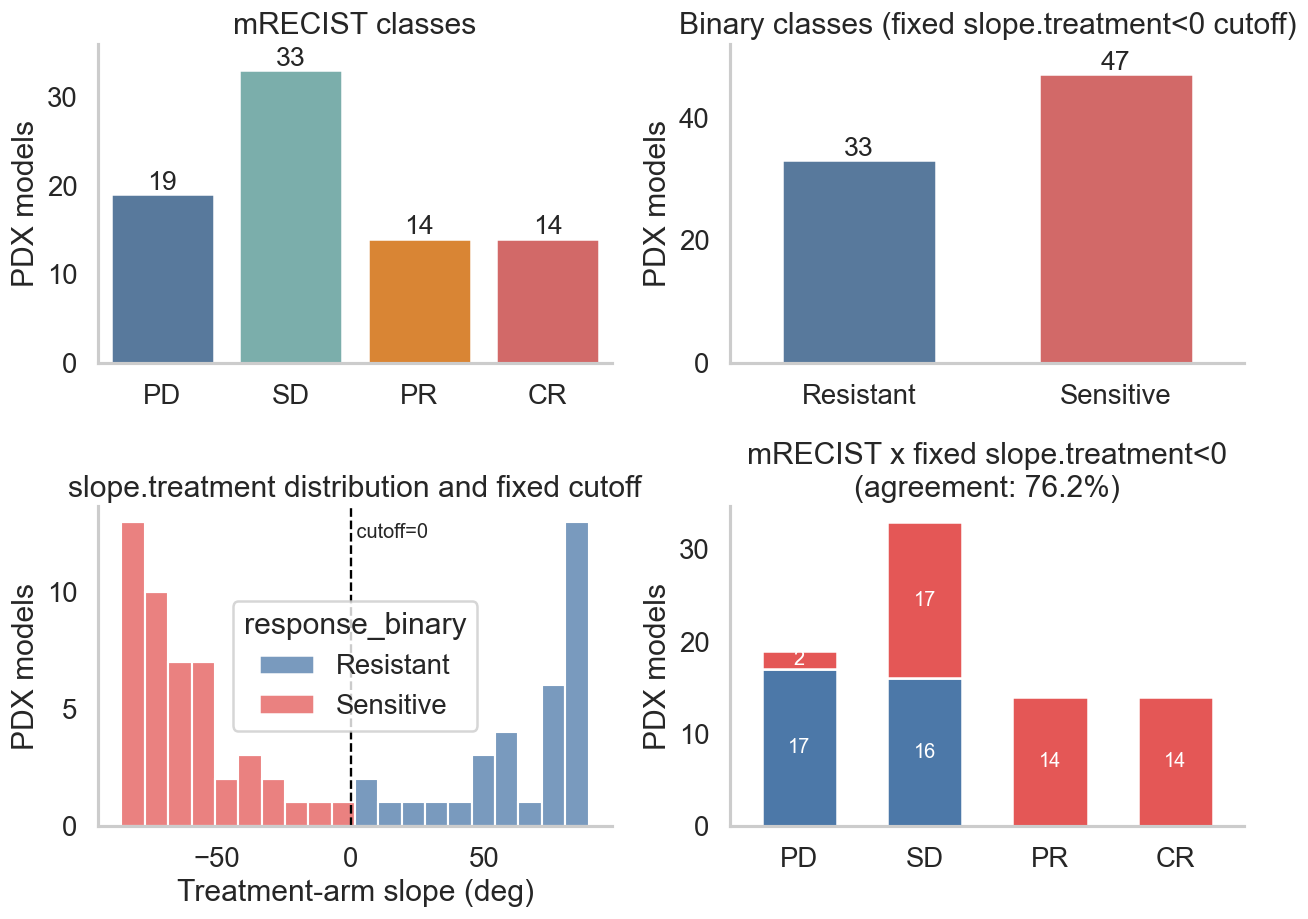

,model.id,mRECIST,slope.treatment,angle,response_binary
0,S66684,SD,-74.658943,150.195285,Sensitive
1,S65465,SD,-71.203209,156.885905,Sensitive
2,REF041,SD,-68.656885,138.655568,Sensitive
3,S85277,PD,-60.929419,145.641352,Sensitive
4,REF025,SD,-57.560135,133.930367,Sensitive
5,S66817,SD,-56.150139,126.983285,Sensitive
6,S17518,SD,-54.589820,142.880996,Sensitive
7,DCPTOB19,SD,-53.243205,117.888330,Sensitive
8,S48041,SD,-52.390662,123.335970,Sensitive
9,S70620,SD,-50.154840,133.267358,Sensitive


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

sns.countplot(
    data=metadata_df,
    x="mRECIST",
    order=MRECIST_ORDER,
    palette=PALETTE_MRECIST,
    ax=axes[0, 0],
)
for p in axes[0, 0].patches:
    height = p.get_height()
    axes[0, 0].annotate(f"{int(height)}", (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='bottom', fontsize=16)
axes[0, 0].set_title("mRECIST classes")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("PDX models")
axes[0, 0].set_ylim(0, metadata_df["mRECIST"].value_counts().max() + 3)

sns.countplot(
    data=metadata_df,
    x="response_binary",
    order=RESPONSE_ORDER,
    palette=PALETTE_BINARY,
    ax=axes[0, 1],
    width=0.6
)
for p in axes[0, 1].patches:
    height = p.get_height()
    axes[0, 1].annotate(f"{int(height)}", (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='bottom', fontsize=16)
axes[0, 1].set_title("Binary classes (fixed slope.treatment<0 cutoff)")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("PDX models")
axes[0, 1].set_ylim(0, metadata_df["response_binary"].value_counts().max() + 5)

# slope.treatment distribution with the fixed 0 deg cutoff. The binary label
# is defined directly from this threshold, so the two groups separate
# perfectly by construction -- this panel illustrates the endpoint
# definition, it is not a hypothesis test (unlike the old mRECIST-based QC,
# slope.treatment-vs-response_binary has no informative p-value here).
sns.histplot(
    data=metadata_df,
    x="slope.treatment",
    hue="response_binary",
    hue_order=RESPONSE_ORDER,
    palette=PALETTE_BINARY,
    multiple="stack",
    bins=20,
    ax=axes[1, 0],
)
sns.move_legend(axes[1, 0], "center")
axes[1, 0].axvline(0, color="black", linestyle="--", linewidth=1.4)
axes[1, 0].text(0, axes[1, 0].get_ylim()[1] * 0.95, " cutoff=0",
                 fontsize=12, va="top")
axes[1, 0].set_title("slope.treatment distribution and fixed cutoff")
axes[1, 0].set_xlabel("Treatment-arm slope (deg)")
axes[1, 0].set_ylabel("PDX models")

# mRECIST x fixed-cutoff concordance -- how the clinical categories relate to
# the modeling endpoint (slope.treatment was chosen over mRECIST as the label
# source; see feature_sets.add_binary_response docstring for why).
concordance = (
    metadata_df.groupby(["mRECIST", "response_binary"]).size().unstack(fill_value=0)
    .reindex(MRECIST_ORDER)[RESPONSE_ORDER]
)
concordance.plot(
    kind="bar", stacked=True,
    color=[PALETTE_BINARY[c] for c in RESPONSE_ORDER],
    ax=axes[1, 1], width=0.6, legend=False,
)
for container in axes[1, 1].containers:
    labels = [f"{int(v)}" if v > 0 else "" for v in container.datavalues]
    axes[1, 1].bar_label(container, labels=labels, label_type="center", fontsize=12, color="white")

mrecist_collapsed = metadata_df["mRECIST"].map(
    {"PD": "Resistant", "SD": "Resistant", "PR": "Sensitive", "CR": "Sensitive"}
)
agreement = (metadata_df["response_binary"] == mrecist_collapsed).mean()
axes[1, 1].set_title(f"mRECIST x fixed slope.treatment<0\n(agreement: {agreement:.1%})")
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("PDX models")
axes[1, 1].tick_params(axis="x", rotation=0)

for ax in axes.flatten():
    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
savefig("response_endpoint_qc")
plt.show()

response_qc_df

## Figure 2: Single-omics and Multi-omics Benchmark

In [5]:
plot_models = [
    ("single_omics", "rna_paired", "random_forest", "RNA only\nRandom forest"),
    ("single_omics", "cnv", "random_forest", "CNV only\nRandom forest"),
    ("single_omics", "mutation", "random_forest", "Mutation only\nRandom forest"),
    ("early_fusion", "rna_cnv_mutation", "random_forest", "Early fusion\nRandom forest"),
    ("late_fusion_stacking", "rna_cnv_mutation", "stack_random_forest", "Late fusion\nRandom forest"),
]

rows = []
for analysis, omics, model, label in plot_models:
    sub = all_results_df[
        (all_results_df["analysis"] == analysis)
        & (all_results_df["omics"] == omics)
        & (all_results_df["model"] == model)
    ].copy()
    if sub.empty:
        print("Missing:", analysis, omics, model)
        continue
    sub["plot_label"] = label
    rows.append(sub)

benchmark_df = pd.concat(rows, ignore_index=True)
benchmark_df["plot_label"] = pd.Categorical(
    benchmark_df["plot_label"],
    categories=[x[3] for x in plot_models],
    ordered=True,
)

benchmark_summary_df = (
    benchmark_df
    .groupby("plot_label", observed=True)[["auroc", "auprc", "balanced_accuracy", "f1"]]
    .agg(["mean", "std"])
    .round(3)
)
benchmark_summary_df


auroc         auprc        balanced_accuracy  \
                               mean    std   mean    std              mean   
plot_label                                                                   
RNA only\nRandom forest       0.711  0.097  0.771  0.102             0.578   
CNV only\nRandom forest       0.449  0.159  0.617  0.105             0.513   
Mutation only\nRandom forest  0.410  0.184  0.582  0.101             0.457   
Early fusion\nRandom forest   0.705  0.106  0.762  0.107             0.606   
Late fusion\nRandom forest    0.641  0.154  0.734  0.121             0.598   

                                        f1         
                                std   mean    std  
plot_label                                         
RNA only\nRandom forest       0.084  0.714  0.083  
CNV only\nRandom forest       0.108  0.650  0.098  
Mutation only\nRandom forest  0.092  0.649  0.074  
Early fusion\nRandom forest   0.097  0.749  0.071  
Late fusion\nRandom forest    0.105  0.629  0.174

saved /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/4_paclitaxel/figures/model_benchmark_auroc.png
saved /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/4_paclitaxel/figures/model_benchmark_auroc.pdf


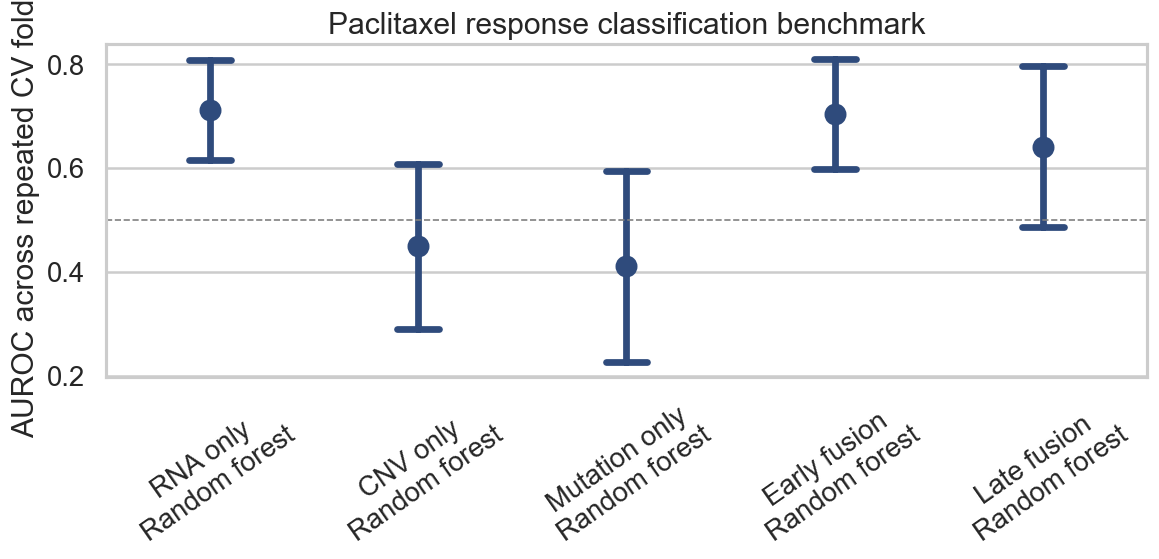

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.pointplot(
    data=benchmark_df,
    x="plot_label",
    y="auroc",
    errorbar="sd",
    join=False,
    capsize=0.2,
    color="#2F4B7C",
    ax=ax,
)
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1)
ax.set_title("Paclitaxel response classification benchmark")
ax.set_xlabel("")
ax.set_ylabel("AUROC across repeated CV folds")
ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
savefig("model_benchmark_auroc")
plt.show()

                              mean    std
Category      Model label                
RNA only      Logistic L2    0.652  0.018
              Random forest  0.711  0.040
CNV only      Logistic L2    0.482  0.013
              Random forest  0.449  0.043
Mutation only Logistic L2    0.359  0.080
              Random forest  0.410  0.092
Early fusion  Logistic L2    0.609  0.026
              Random forest  0.705  0.029
Late fusion   Logistic L2    0.614  0.040
              Random forest  0.641  0.058


saved /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/4_paclitaxel/figures/model_benchmark_multi_metric.png
saved /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/4_paclitaxel/figures/model_benchmark_multi_metric.pdf


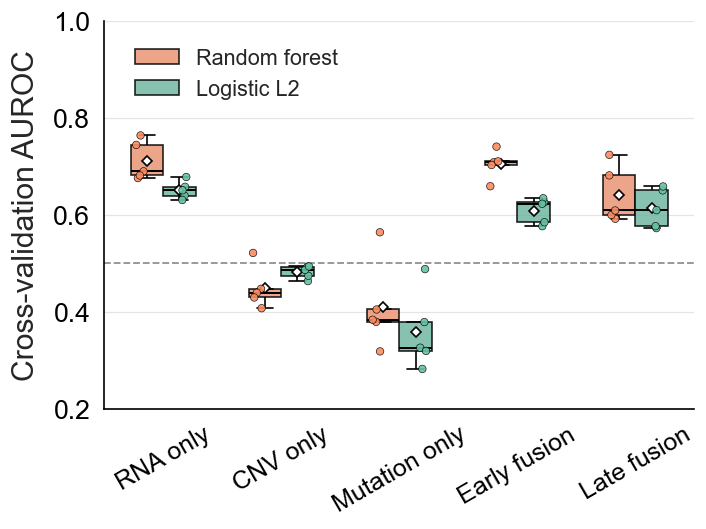

In [7]:
# Figure 5b: grouped box plot of both tested models (Random forest, Logistic
# L2) across all 5 categories -- case study 1's Figure 2e already reports
# every model it tested (ElasticNet/RF/LassoedForest) rather than one curated
# model, so this matches that convention instead of showing Random forest
# alone. Self-contained (rebuilds its own repeat-aggregated frame from
# all_results_df) so it doesn't depend on plot_models/benchmark_df above,
# which stay Random-forest-only for the separate point-range summary plot.
#
# Repeat-level AUROC (mean across the N_SPLITS folds within each CV repeat,
# not all 25 raw folds) -- same aggregation convention as case study 1's
# Figure 2e, avoiding pseudo-replication from plotting correlated
# within-repeat folds as if independent.
N_SPLITS = 5  # matches 2-ML.ipynb's RepeatedStratifiedKFold(n_splits=5, n_repeats=5)

fig5b_configs = [
    ("single_omics", "rna_paired", "RNA only"),
    ("single_omics", "cnv", "CNV only"),
    ("single_omics", "mutation", "Mutation only"),
    ("early_fusion", "rna_cnv_mutation", "Early fusion"),
    ("late_fusion_stacking", "rna_cnv_mutation", "Late fusion"),
]
# late_fusion_stacking's model column is prefixed "stack_"; single_omics/
# early_fusion are not -- map each category's analysis to the actual
# model-column value for each display model label.
FIG5B_MODEL_VARIANTS = {
    "single_omics": {"Random forest": "random_forest", "Logistic L2": "logistic_l2"},
    "early_fusion": {"Random forest": "random_forest", "Logistic L2": "logistic_l2"},
    "late_fusion_stacking": {"Random forest": "stack_random_forest", "Logistic L2": "stack_logistic_l2"},
}
fig5b_model_colors = {"Random forest": "#fc8d62", "Logistic L2": "#66c2a5"}
fig5b_hue_order = ["Random forest", "Logistic L2"]
fig5b_category_order = [label for _, _, label in fig5b_configs]

fig5b_rows = []
for analysis, omics, category_label in fig5b_configs:
    for model_label, model_col in FIG5B_MODEL_VARIANTS[analysis].items():
        sub = all_results_df[
            (all_results_df["analysis"] == analysis)
            & (all_results_df["omics"] == omics)
            & (all_results_df["model"] == model_col)
        ][["fold", "auroc"]].dropna().copy()
        if sub.empty:
            print("Missing:", analysis, omics, model_col)
            continue
        sub["Repeat"] = ((sub["fold"].astype(int) - 1) // N_SPLITS) + 1
        sub = sub.groupby("Repeat", as_index=False)["auroc"].mean()
        sub["Category"] = category_label
        sub["Model label"] = model_label
        fig5b_rows.append(sub)

fig5b_df = pd.concat(fig5b_rows, ignore_index=True)
fig5b_df["Category"] = pd.Categorical(fig5b_df["Category"], categories=fig5b_category_order, ordered=True)

fig5b_summary_df = (
    fig5b_df
    .groupby(["Category", "Model label"], observed=True)["auroc"]
    .agg(["mean", "std"])
    .round(3)
)
print(fig5b_summary_df)

# Nature-style grouped box plots with every repeat-level value visible --
# same styling convention as case study 1's Figure 2e (dataset x model), here
# for category (omics/fusion strategy) x model.
sns.set_theme(style="whitegrid", context="paper", font="Arial")
fig, ax = plt.subplots(figsize=(6, 4.5))

sns.boxplot(
    data=fig5b_df, x="Category", y="auroc", hue="Model label",
    order=fig5b_category_order, hue_order=fig5b_hue_order, palette=fig5b_model_colors,
    width=0.55, linewidth=1.0, showfliers=False, showmeans=True,
    meanprops={"marker": "D", "markerfacecolor": "white",
               "markeredgecolor": "black", "markersize": 4},
    boxprops={"edgecolor": "black", "linewidth": 1.0, "alpha": 0.85},
    whiskerprops={"color": "black", "linewidth": 1.0},
    capprops={"color": "black", "linewidth": 1.0},
    medianprops={"color": "black", "linewidth": 1.2}, ax=ax,
)
sns.stripplot(
    data=fig5b_df, x="Category", y="auroc", hue="Model label",
    order=fig5b_category_order, hue_order=fig5b_hue_order, palette=fig5b_model_colors,
    dodge=True, jitter=0.08, size=4.5, alpha=0.9,
    edgecolor="black", linewidth=0.4, legend=False, ax=ax, zorder=3,
)

ax.axhline(0.5, color="#777777", linestyle="--", linewidth=1.1, alpha=0.8, zorder=0)
ax.set_xlabel("")
ax.set_ylabel("Cross-validation AUROC", fontsize=18, labelpad=8)
ax.tick_params(axis="x", labelsize=15, colors="black", width=1.0, rotation=30)
ax.tick_params(axis="y", labelsize=16, colors="black", width=1.0)
ax.set_ylim(0.2, 1)
ax.legend(title="", loc="upper left", bbox_to_anchor=(0.02, 0.98),
          fontsize=13, frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("black")
ax.spines["bottom"].set_color("black")
ax.spines["left"].set_linewidth(1.0)
ax.spines["bottom"].set_linewidth(1.0)
ax.grid(axis="y", color="#D9D9D9", linewidth=0.7, alpha=0.7, zorder=0)

plt.tight_layout()
savefig("model_benchmark_multi_metric")
plt.show()

## Figure 3: ROC and Precision-Recall Curves for Representative Models

Curves pool held-out predictions across repeated CV folds. Because each sample appears in multiple held-out folds across repeats, these curves are descriptive summaries of cross-validated predictions.

saved /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/4_paclitaxel/figures/roc_curves_representative_models.png
saved /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/4_paclitaxel/figures/roc_curves_representative_models.pdf


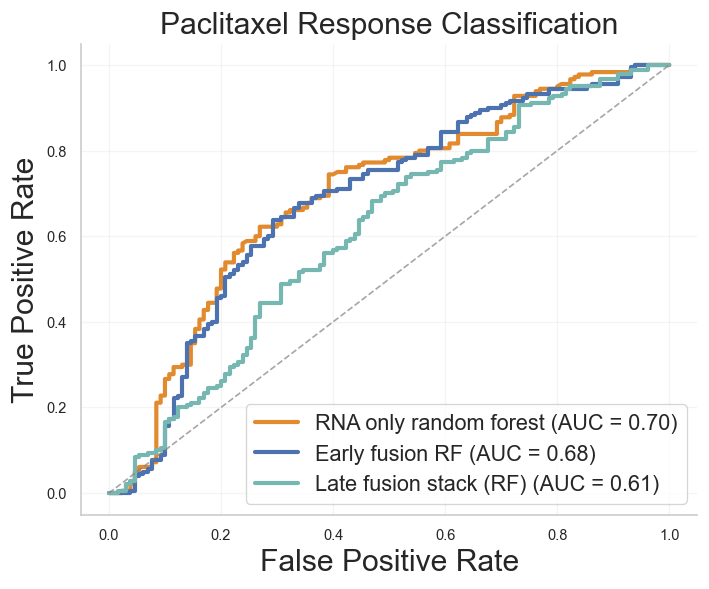

In [8]:
curve_models = [
    ("single_omics", "rna_paired", "random_forest", "RNA only random forest", "#E28A2E"),
    ("early_fusion", "rna_cnv_mutation", "random_forest", "Early fusion RF", "#4C72B0"),
    ("late_fusion_stacking", "rna_cnv_mutation", "stack_random_forest", "Late fusion stack (RF)", "#76B7B2"),
]

fig, ax = plt.subplots(figsize=(6, 5))

for analysis, omics, model, label, color in curve_models:
    try:
        sub = pooled_curve_data(all_predictions_df, model=model, analysis=analysis, omics=omics)
    except ValueError as err:
        print(err)
        continue

    fpr, tpr, _ = roc_curve(sub["y_true"], sub["y_score_sensitive"])
    roc_val = roc_auc_score(sub["y_true"], sub["y_score_sensitive"])
    ax.plot(fpr, tpr, linewidth=2.5, label=f"{label} (AUC = {roc_val:.2f})", color=color)

ax.plot([0, 1], [0, 1], color="gray", linewidth=1, linestyle="--", alpha=0.7)
ax.set_title("Paclitaxel Response Classification", fontsize=18)
ax.set_xlabel("False Positive Rate", fontsize=18)
ax.set_ylabel("True Positive Rate", fontsize=18)
ax.legend(loc="lower right", fontsize=13)
ax.grid(alpha=0.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
savefig("roc_curves_representative_models")
plt.show()

## Figure 4: Prediction Score Distributions

saved /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/4_paclitaxel/figures/early_fusion_rf_prediction_scores.png
saved /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/4_paclitaxel/figures/early_fusion_rf_prediction_scores.pdf


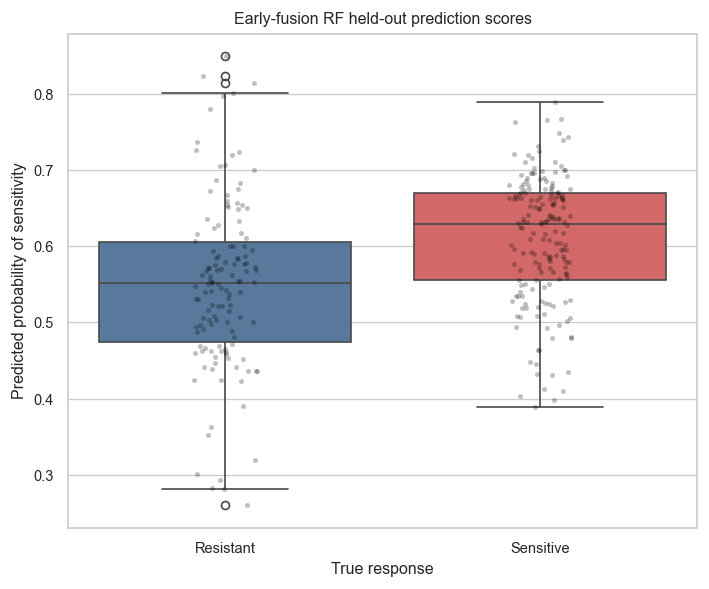

Mann-Whitney p: 2.9538730649257174e-08


In [9]:
best_pred_df = pooled_curve_data(
    all_predictions_df,
    model="random_forest",
    analysis="early_fusion",
    omics="rna_cnv_mutation",
).copy()
best_pred_df["true_response"] = best_pred_df["y_true_label"]

fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(
    data=best_pred_df,
    x="true_response",
    y="y_score_sensitive",
    order=RESPONSE_ORDER,
    palette=PALETTE_BINARY,
    ax=ax,
)
sns.stripplot(
    data=best_pred_df,
    x="true_response",
    y="y_score_sensitive",
    order=RESPONSE_ORDER,
    color="black",
    alpha=0.25,
    size=3,
    ax=ax,
)
ax.set_title("Early-fusion RF held-out prediction scores")
ax.set_xlabel("True response")
ax.set_ylabel("Predicted probability of sensitivity")
plt.tight_layout()
savefig("early_fusion_rf_prediction_scores")
plt.show()

resistant = best_pred_df.loc[best_pred_df["true_response"] == "Resistant", "y_score_sensitive"]
sensitive = best_pred_df.loc[best_pred_df["true_response"] == "Sensitive", "y_score_sensitive"]
print("Mann-Whitney p:", mannwhitneyu(resistant, sensitive, alternative="two-sided").pvalue)

In [10]:
# Same Mann-Whitney U test printed above, saved as a table.
mw_stat, mw_p = mannwhitneyu(resistant, sensitive, alternative="two-sided")
best_model_mw_test = pd.DataFrame([{
    "analysis": "early_fusion", "omics": "rna_cnv_mutation", "model": "random_forest",
    "U_stat": mw_stat, "p_value": mw_p,
    "n_resistant": len(resistant), "n_sensitive": len(sensitive),
}])
best_model_mw_test_file = paths["results"] / "early_fusion_rf_prediction_scores_mannwhitney.csv"
best_model_mw_test.to_csv(best_model_mw_test_file, index=False)
print(f"Saved: {best_model_mw_test_file}")
best_model_mw_test

Saved: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/4_paclitaxel/early_fusion_rf_prediction_scores_mannwhitney.csv


,analysis,omics,model,U_stat,p_value,n_resistant,n_sensitive
0,early_fusion,rna_cnv_mutation,random_forest,7382.0,2.953873e-08,130,180


## Figure 5: RNA Feature Importance (Best Single-omics Model)

A single random forest is fit on the full `rna_all` cohort (all 67 models) using the same fold-safe feature-selection pipeline as the CV evaluation, purely to inspect which genes drive the model. This fit is not used for any performance metric -- scoring it on its own training data would be circular; the actual AUROC estimate is the cross-validated one from Figures 2-4.

saved /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/4_paclitaxel/figures/rna_feature_importance_top25.png
saved /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/4_paclitaxel/figures/rna_feature_importance_top25.pdf


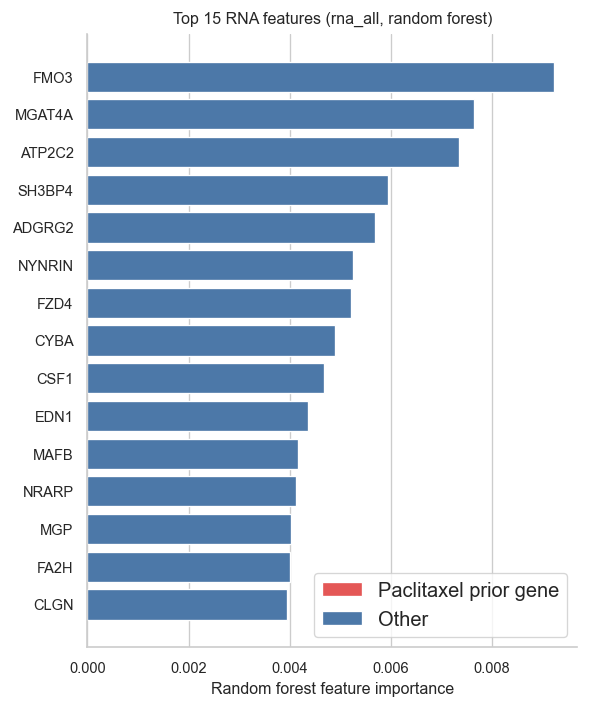

0/15 top features are paclitaxel-prior genes (prior list size=69, selected feature count=2046)


,gene,importance,is_pax_prior
0,FMO3,0.009225,False
1,MGAT4A,0.007632,False
2,ATP2C2,0.007341,False
3,SH3BP4,0.005940,False
4,ADGRG2,0.005680,False
5,NYNRIN,0.005241,False
6,FZD4,0.005206,False
7,CYBA,0.004900,False
8,CSF1,0.004675,False
9,EDN1,0.004369,False


In [11]:
X_rna_all, y_rna_all = split_x_class_y(rna_df)
rna_all_selected = select_features_by_omics(
    "rna_all", X_rna_all, prior_mode="pax", pax_genes=pax_genes, nest_genes=nest_genes
)
X_rna_all_selected = X_rna_all[rna_all_selected]

rf_importance_model = RandomForestClassifier(
    n_estimators=500,
    max_features="sqrt",
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_importance_model.fit(X_rna_all_selected, y_rna_all)

importance_df = pd.DataFrame({
    "gene": rna_all_selected,
    "importance": rf_importance_model.feature_importances_,
})
importance_df["is_pax_prior"] = importance_df["gene"].isin(pax_genes)
importance_df = importance_df.sort_values("importance", ascending=False).reset_index(drop=True)

TOP_N = 15
top_df = importance_df.head(TOP_N).iloc[::-1]

fig, ax = plt.subplots(figsize=(5, 6))
bar_colors = top_df["is_pax_prior"].map({True: PALETTE_BINARY["Sensitive"], False: PALETTE_BINARY["Resistant"]})
ax.barh(top_df["gene"], top_df["importance"], color=bar_colors)
ax.set_xlabel("Random forest feature importance")
ax.set_title(f"Top {TOP_N} RNA features (rna_all, random forest)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False, axis="y")

legend_elements = [
    Patch(facecolor=PALETTE_BINARY["Sensitive"], label="Paclitaxel prior gene"),
    Patch(facecolor=PALETTE_BINARY["Resistant"], label="Other"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=12)

plt.tight_layout()
savefig("rna_feature_importance_top25")
plt.show()

n_pax_in_top = int(top_df["is_pax_prior"].sum())
print(
    f"{n_pax_in_top}/{TOP_N} top features are paclitaxel-prior genes "
    f"(prior list size={len(pax_genes)}, selected feature count={len(rna_all_selected)})"
)

importance_df.to_csv(RESULTS_DIR / "rna_feature_importance.csv", index=False)
importance_df.head(TOP_N)

### Figure 5b: Top paclitaxel-prior-gene features

Same random forest fit and `importance_df` as Figure 5 above (not refit) -- filtered to just the genes in the curated paclitaxel prior list (`is_pax_prior`), ranked by the same feature importance. `force_retain_prior_genes` (in `select_features_by_omics`) guarantees every prior gene present in the RNA matrix is force-included in the selected feature set, so this is the full prior-gene ranking, not a subsample.

saved /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/4_paclitaxel/figures/rna_feature_importance_pax_prior_top25.png
saved /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/4_paclitaxel/figures/rna_feature_importance_pax_prior_top25.pdf


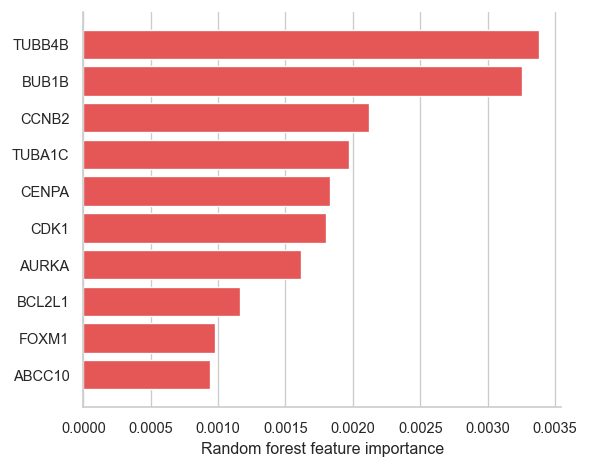

60/69 paclitaxel-prior genes present in the selected feature set (showing top 10)


,gene,importance,is_pax_prior
0,TUBB4B,0.003379,True
1,BUB1B,0.003252,True
2,CCNB2,0.002120,True
3,TUBA1C,0.001969,True
4,CENPA,0.001831,True
5,CDK1,0.001804,True
6,AURKA,0.001618,True
7,BCL2L1,0.001165,True
8,FOXM1,0.000977,True
9,ABCC10,0.000941,True


In [12]:
pax_importance_df = importance_df[importance_df["is_pax_prior"]].reset_index(drop=True)

TOP_N_PAX = 10
n_pax_available = len(pax_importance_df)
top_pax_df = pax_importance_df.head(TOP_N_PAX).iloc[::-1]

fig, ax = plt.subplots(figsize=(5, 4))
ax.barh(top_pax_df["gene"], top_pax_df["importance"], color=PALETTE_BINARY["Sensitive"])
ax.set_xlabel("Random forest feature importance")
#ax.set_title(f"Top {len(top_pax_df)} paclitaxel-prior-gene features (rna_all, random forest)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False, axis="y")

plt.tight_layout()
savefig("rna_feature_importance_pax_prior_top25")
plt.show()

print(
    f"{n_pax_available}/{len(pax_genes)} paclitaxel-prior genes present in the selected feature set "
    f"(showing top {len(top_pax_df)})"
)

pax_importance_df.to_csv(RESULTS_DIR / "rna_feature_importance_pax_prior.csv", index=False)
pax_importance_df.head(TOP_N_PAX)

## Figure 6: RNA Pathway Enrichment (GSEA)

Every gene in the full `rna_all` matrix (all ~49k genes, not the ~2,000 features pre-filtered for classification) is ranked by a Welch's t-statistic comparing Sensitive vs Resistant models (fixed slope.treatment<0 cutoff, n=67), then tested with pre-ranked GSEA against MSigDB Hallmark, KEGG, and GO Biological Process gene sets. Positive NES = enriched in Sensitive models; negative NES = enriched in Resistant models. This is a separate, complementary view to the single-gene importance panel in Figure 5 -- it asks whether the RNA signal aggregates into coherent biological pathways rather than isolated genes.

In [13]:
import subprocess

import gseapy as gp

GSEA_PERMUTATIONS = 5000
GSEA_MIN_SIZE = 15
GSEA_MAX_SIZE = 500
GSEA_FDR_THRESHOLD = 0.05
GSEA_TOP_PER_DIRECTION = 4
GSEA_SEED = 42

gsea_gene_set_libraries = {
    "GO Biological Process": "GO_Biological_Process_2023",
    "KEGG": "KEGG_2021_Human",
    "MSigDB Hallmark": "MSigDB_Hallmark_2020",
}

# Rank every gene in the full RNA matrix (not the pre-filtered classification
# feature set) by limma's empirical-Bayes moderated t-statistic between
# Sensitive and Resistant rna_all models: per-gene variance estimates are
# shrunk toward a prior fitted across the whole population of genes measured
# on the same samples, the more principled estimator than a per-gene Welch's
# t for this small a cohort. Positive statistic = higher expression in
# Sensitive models.
rna_expr_all = rna_df.drop(columns=[c for c in ["angle", "slope.treatment", "mRECIST", "response_binary", "response_binary_num"] if c in rna_df.columns])
sensitive_mask = rna_df["response_binary"] == "Sensitive"
resistant_mask = rna_df["response_binary"] == "Resistant"

limma_input_file = DATA_DIR / "limma_ranking_input_rna_all.csv"
limma_output_file = DATA_DIR / "limma_ranking_output_rna_all.csv"
limma_input = rna_expr_all.loc[sensitive_mask | resistant_mask].apply(pd.to_numeric, errors="coerce").copy()
limma_input["group"] = np.where(sensitive_mask.loc[limma_input.index], "Sensitive", "Resistant")
limma_input.to_csv(limma_input_file)
subprocess.run(
    ["Rscript", "compute_limma_ranking.R", str(limma_input_file), "group", "Resistant", "Sensitive", str(limma_output_file)],
    check=True,
)
limma_result = pd.read_csv(limma_output_file).set_index("Gene")

gsea_rank_table = pd.DataFrame({
    "Gene": rna_expr_all.columns,
    "ranking_statistic": limma_result["ranking_statistic"].reindex(rna_expr_all.columns).to_numpy(),
    "unadjusted_p_value": limma_result["unadjusted_p_value"].reindex(rna_expr_all.columns).to_numpy(),
})
gsea_rank_table = (
    gsea_rank_table.replace([np.inf, -np.inf], np.nan)
    .dropna(subset=["ranking_statistic"])
    .sort_values("ranking_statistic", ascending=False)
    .reset_index(drop=True)
)
gsea_rank_table.to_csv(RESULTS_DIR / "rna_gsea_gene_ranking.csv", index=False)
print(
    f"Ranked {len(gsea_rank_table):,} genes "
    f"({int(sensitive_mask.sum())} Sensitive vs {int(resistant_mask.sum())} Resistant, rna_all, limma moderated-t)"
)

gsea_results = {}
for collection_label, library_name in gsea_gene_set_libraries.items():
    enrichment = gp.prerank(
        rnk=gsea_rank_table[["Gene", "ranking_statistic"]],
        gene_sets=library_name,
        min_size=GSEA_MIN_SIZE, max_size=GSEA_MAX_SIZE,
        permutation_num=GSEA_PERMUTATIONS,
        threads=4, seed=GSEA_SEED,
        outdir=None, no_plot=True, verbose=False,
    )
    result = enrichment.res2d.copy()
    result["NES"] = result["NES"].astype(float)
    result["FDR q-val"] = result["FDR q-val"].astype(float)
    result["Collection"] = collection_label
    result["Direction"] = np.where(result["NES"] > 0, "Sensitive", "Resistant")
    gsea_results[collection_label] = result
    output_name = collection_label.lower().replace(" ", "_")
    result.to_csv(RESULTS_DIR / f"rna_gsea_{output_name}.csv", index=False)

for collection_label, result in gsea_results.items():
    n_sig = (result["FDR q-val"] < GSEA_FDR_THRESHOLD).sum()
    print(f"{collection_label}: {n_sig}/{len(result)} gene sets significant at FDR < {GSEA_FDR_THRESHOLD}")

2026-09-28 16:17:57,495 [WARNING] Duplicated values found in preranked stats: 0.01% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


Group counts:
group
Resistant Sensitive 
       28        39 
Saved limma moderated-t ranking: 14020 genes to /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/4_paclitaxel/limma_ranking_output_rna_all.csv 
Ranked 14,020 genes (39 Sensitive vs 28 Resistant, rna_all, limma moderated-t)


2026-09-28 16:19:16,217 [WARNING] Duplicated values found in preranked stats: 0.01% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


2026-09-28 16:19:28,432 [WARNING] Duplicated values found in preranked stats: 0.01% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


GO Biological Process: 43/2199 gene sets significant at FDR < 0.05
KEGG: 18/293 gene sets significant at FDR < 0.05
MSigDB Hallmark: 4/50 gene sets significant at FDR < 0.05


saved /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/4_paclitaxel/figures/rna_gsea_pathways.png
saved /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/4_paclitaxel/figures/rna_gsea_pathways.pdf


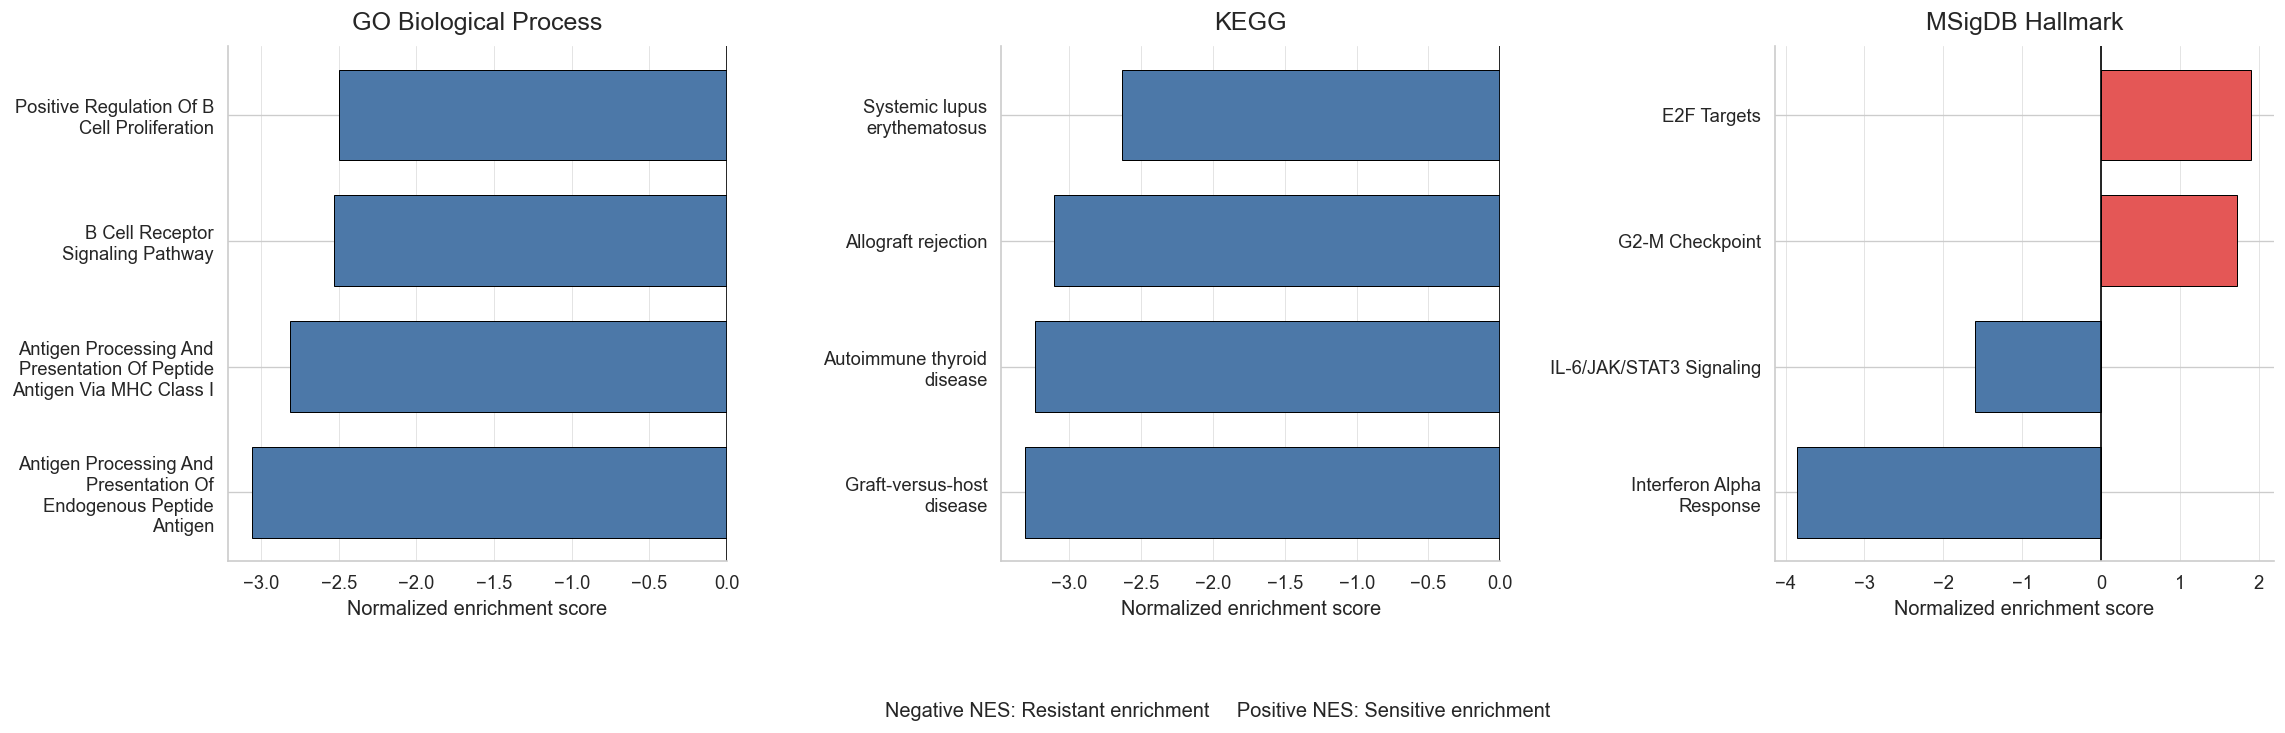

In [14]:
import textwrap


def select_pathways_for_plot(result):
    significant = result.loc[result["FDR q-val"] < GSEA_FDR_THRESHOLD].copy()
    sensitive_top = (
        significant.loc[significant["NES"] > 0]
        .sort_values(["FDR q-val", "NES"], ascending=[True, False])
        .head(GSEA_TOP_PER_DIRECTION)
    )
    resistant_top = (
        significant.loc[significant["NES"] < 0]
        .sort_values(["FDR q-val", "NES"], ascending=[True, True])
        .head(GSEA_TOP_PER_DIRECTION)
    )
    return pd.concat([resistant_top, sensitive_top]).sort_values("NES")


def format_pathway_name(term, collection_label):
    term = str(term).split(" (GO:")[0]
    if collection_label == "MSigDB Hallmark":
        # gseapy's Hallmark Term values already arrive correctly cased (e.g.
        # "mTORC1 Signaling", "PI3K/AKT/mTOR  Signaling", "IL-6/JAK/STAT3
        # Signaling") -- .title() previously mangled these (mTORC1 -> Mtorc1),
        # and force-uppercasing just the first letter is equally wrong the
        # other way (mTORC1 -> MTORC1, when the lowercase m is intentional,
        # like mRNA). Trust gseapy's casing as-is rather than "fixing" it.
        term = term.replace("HALLMARK_", "").replace("_", " ")
    return "\n".join(textwrap.wrap(term, width=24))


fig, axes = plt.subplots(1, 3, figsize=(22, 6.5))
for ax, (collection_label, result) in zip(axes, gsea_results.items()):
    plot_data = select_pathways_for_plot(result)
    if plot_data.empty:
        ax.text(
            0.5, 0.5, f"No pathways at FDR < {GSEA_FDR_THRESHOLD:.2f}",
            transform=ax.transAxes, ha="center", va="center", fontsize=11,
        )
        ax.set_yticks([])
    else:
        labels = [format_pathway_name(term, collection_label) for term in plot_data["Term"]]
        colors = [
            PALETTE_BINARY["Sensitive"] if nes > 0 else PALETTE_BINARY["Resistant"]
            for nes in plot_data["NES"]
        ]
        ax.barh(labels, plot_data["NES"], color=colors, edgecolor="black", linewidth=0.6, height=0.72)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_title(collection_label, fontsize=15, pad=10)
    ax.set_xlabel("Normalized enrichment score", fontsize=12)
    ax.tick_params(axis="both", labelsize=11)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="x", color="#D9D9D9", linewidth=0.6, alpha=0.7)
    ax.set_axisbelow(True)

fig.subplots_adjust(wspace=0.55, bottom=0.22)
fig.text(
    0.5, 0.02,
    "Negative NES: Resistant enrichment     Positive NES: Sensitive enrichment",
    ha="center", fontsize=12,
)
savefig("rna_gsea_pathways")
plt.show()

### Supplementary: top 6 pathways per direction

The main Figure 6 panel above shows the top 4 significant pathways per direction per collection. Some pathways discussed in the text (e.g., Hallmark's DNA Repair, TNF-alpha Signaling via NF-kB, and IL-6/JAK/STAT3 Signaling) are significant but fall just outside that top-4 cutoff. This panel reuses the same `gsea_results` (no GSEA recomputation) with `GSEA_TOP_PER_DIRECTION = 6` to show a fuller picture.

saved /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/4_paclitaxel/figures/rna_gsea_pathways_top6.png
saved /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/4_paclitaxel/figures/rna_gsea_pathways_top6.pdf


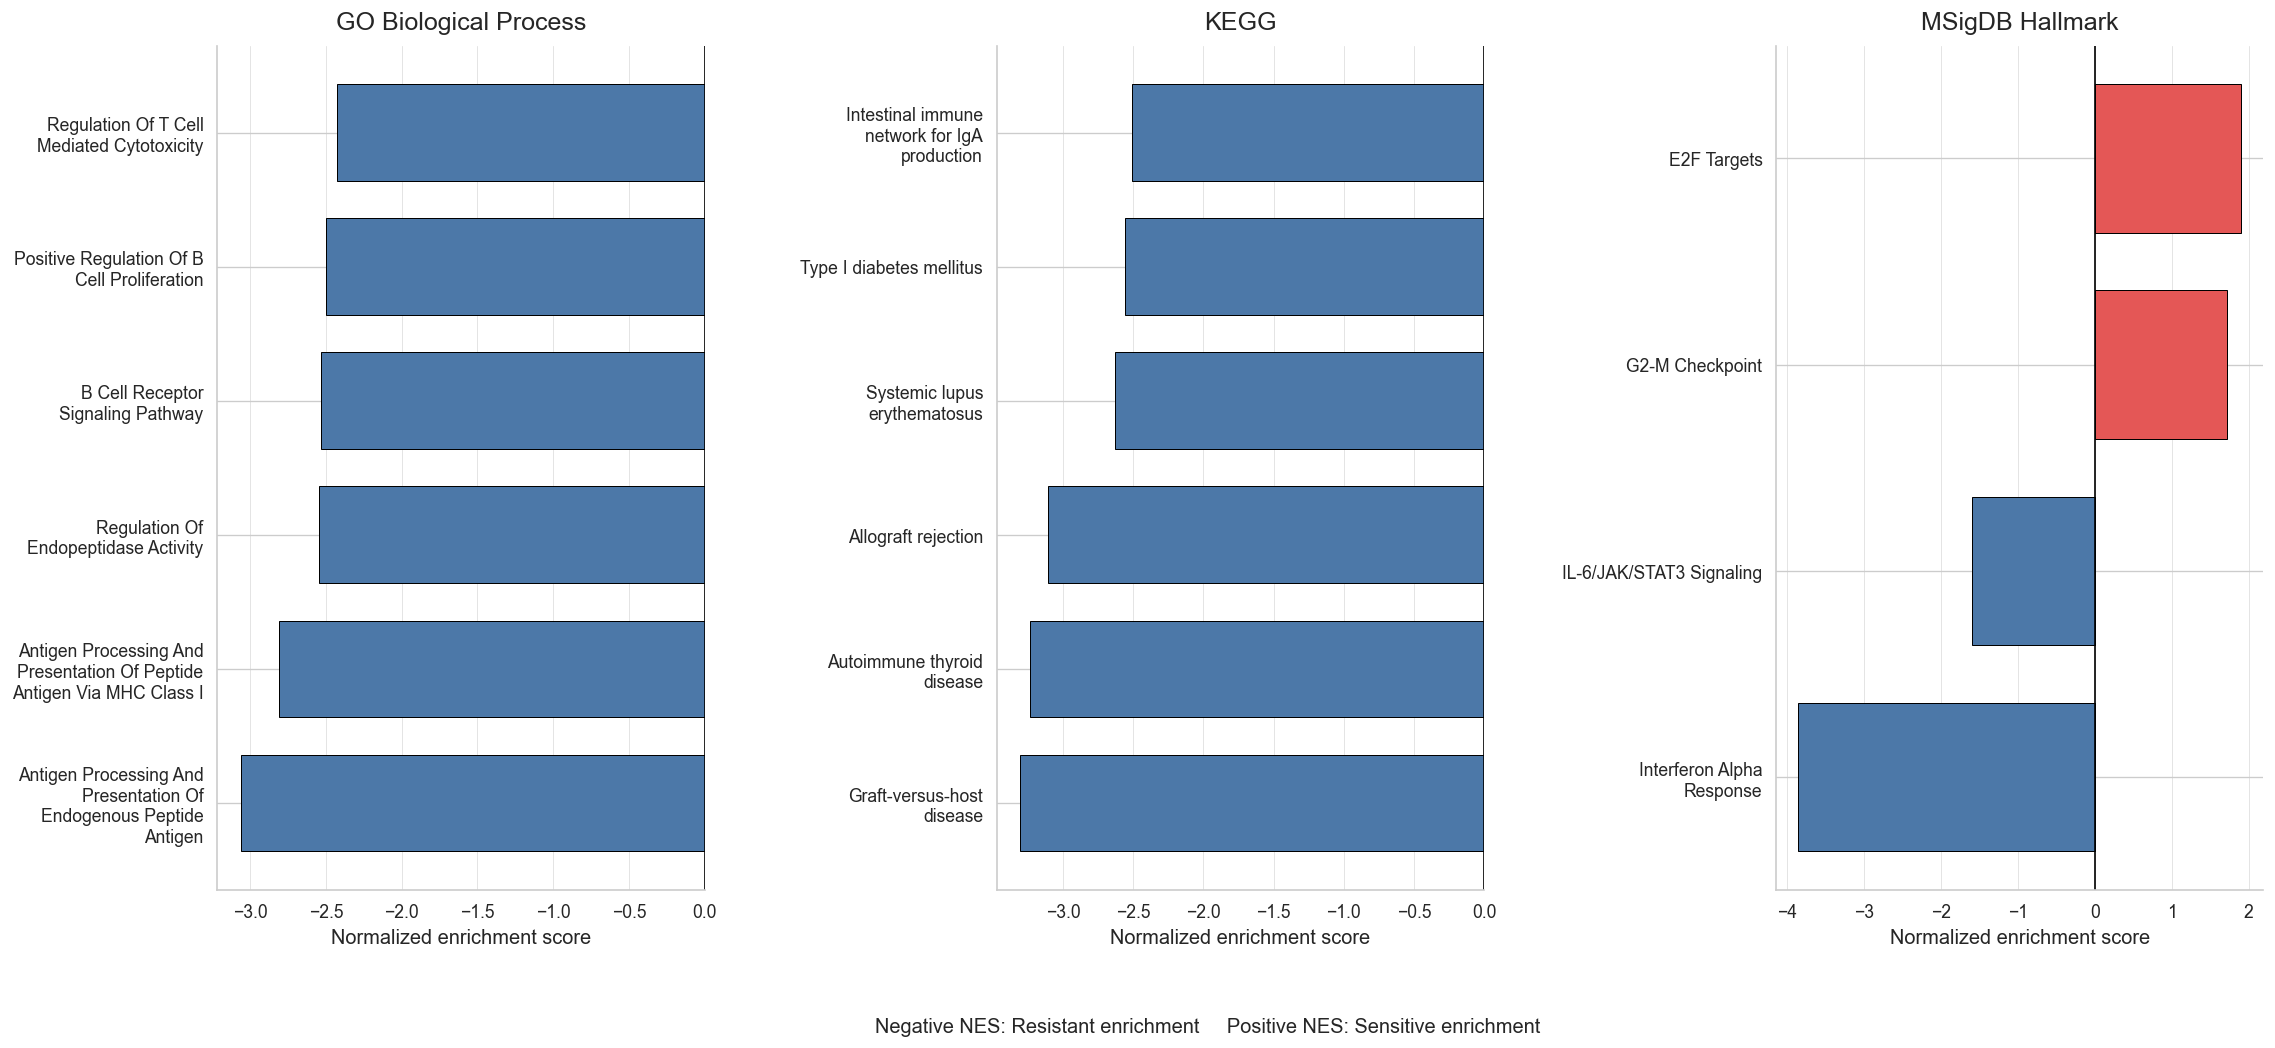

In [15]:
GSEA_TOP_PER_DIRECTION_SUPP = 6

fig, axes = plt.subplots(1, 3, figsize=(22, 9.5))
for ax, (collection_label, result) in zip(axes, gsea_results.items()):
    significant = result.loc[result["FDR q-val"] < GSEA_FDR_THRESHOLD].copy()
    sensitive_top = (
        significant.loc[significant["NES"] > 0]
        .sort_values(["FDR q-val", "NES"], ascending=[True, False])
        .head(GSEA_TOP_PER_DIRECTION_SUPP)
    )
    resistant_top = (
        significant.loc[significant["NES"] < 0]
        .sort_values(["FDR q-val", "NES"], ascending=[True, True])
        .head(GSEA_TOP_PER_DIRECTION_SUPP)
    )
    plot_data = pd.concat([resistant_top, sensitive_top]).sort_values("NES")

    if plot_data.empty:
        ax.text(
            0.5, 0.5, f"No pathways at FDR < {GSEA_FDR_THRESHOLD:.2f}",
            transform=ax.transAxes, ha="center", va="center", fontsize=11,
        )
        ax.set_yticks([])
    else:
        labels = [format_pathway_name(term, collection_label) for term in plot_data["Term"]]
        colors = [
            PALETTE_BINARY["Sensitive"] if nes > 0 else PALETTE_BINARY["Resistant"]
            for nes in plot_data["NES"]
        ]
        ax.barh(labels, plot_data["NES"], color=colors, edgecolor="black", linewidth=0.6, height=0.72)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_title(collection_label, fontsize=15, pad=10)
    ax.set_xlabel("Normalized enrichment score", fontsize=12)
    ax.tick_params(axis="both", labelsize=10.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="x", color="#D9D9D9", linewidth=0.6, alpha=0.7)
    ax.set_axisbelow(True)

fig.subplots_adjust(wspace=0.6, bottom=0.14)
fig.text(
    0.5, 0.015,
    "Negative NES: Resistant enrichment     Positive NES: Sensitive enrichment",
    ha="center", fontsize=12,
)
savefig("rna_gsea_pathways_top6")
plt.show()

### Supplementary: MSigDB Hallmark only, top 6 per direction, larger labels

Single-panel version of the Hallmark third of the supplementary top-6 plot above, sized and fonted for standalone use (e.g. as a main-text panel) rather than as one of three cramped subplots. Reuses `gsea_results["MSigDB Hallmark"]` and `GSEA_TOP_PER_DIRECTION_SUPP` -- no recomputation.

saved /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/4_paclitaxel/figures/rna_gsea_hallmark_top5_large.png
saved /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/4_paclitaxel/figures/rna_gsea_hallmark_top5_large.pdf


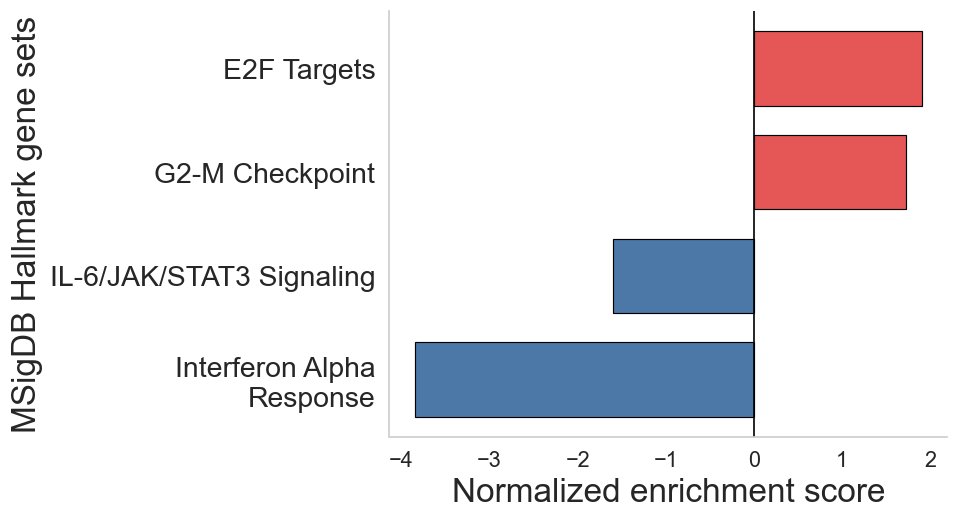

In [16]:
HALLMARK_TOP_PER_DIRECTION = 5  # independent of GSEA_TOP_PER_DIRECTION_SUPP (cell above),
# which drives the separate 3-collection "rna_gsea_pathways_top6" supplementary figure
hallmark_result = gsea_results["MSigDB Hallmark"]
significant = hallmark_result.loc[hallmark_result["FDR q-val"] < GSEA_FDR_THRESHOLD].copy()
sensitive_top = (
    significant.loc[significant["NES"] > 0]
    .sort_values(["FDR q-val", "NES"], ascending=[True, False])
    .head(HALLMARK_TOP_PER_DIRECTION)
)
resistant_top = (
    significant.loc[significant["NES"] < 0]
    .sort_values(["FDR q-val", "NES"], ascending=[True, True])
    .head(HALLMARK_TOP_PER_DIRECTION)
)
plot_data = pd.concat([resistant_top, sensitive_top]).sort_values("NES")

# Height scales with the actual number of significant pathways rather than a
# fixed guess (originally tuned for 10 bars/5-per-direction; now typically far
# fewer since the RNA gene-filtering fix), so the panel doesn't end up mostly
# empty when fewer pathways clear FDR<0.05. Floor is 4.6, not bar-count-driven --
# below that, the y-axis label text itself ("MSigDB Hallmark gene sets" at
# fontsize 20) no longer fits and gets clipped, independent of bar count.
fig_height = max(4.6, 1.6 + 0.65 * max(len(plot_data), 1))
fig, ax = plt.subplots(figsize=(6, fig_height))
if plot_data.empty:
    ax.text(
        0.5, 0.5, f"No pathways at FDR < {GSEA_FDR_THRESHOLD:.2f}",
        transform=ax.transAxes, ha="center", va="center", fontsize=14,
    )
    ax.set_yticks([])
else:
    labels = [format_pathway_name(term, "MSigDB Hallmark") for term in plot_data["Term"]]
    colors = [
        PALETTE_BINARY["Sensitive"] if nes > 0 else PALETTE_BINARY["Resistant"]
        for nes in plot_data["NES"]
    ]
    ax.barh(labels, plot_data["NES"], color=colors, edgecolor="black", linewidth=0.7, height=0.72)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Normalized enrichment score", fontsize=20)
ax.set_ylabel("MSigDB Hallmark gene sets", fontsize=20)
ax.tick_params(axis="x", labelsize=13)
ax.tick_params(axis="y", labelsize=17)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)

savefig("rna_gsea_hallmark_top5_large")
plt.show()

## Export Manuscript Summary Tables

In [17]:
benchmark_summary_flat_df = (
    benchmark_df
    .groupby(["plot_label", "analysis", "omics", "model"], observed=True)
    .agg(
        auroc_mean=("auroc", "mean"),
        auroc_sd=("auroc", "std"),
        auprc_mean=("auprc", "mean"),
        auprc_sd=("auprc", "std"),
        balanced_accuracy_mean=("balanced_accuracy", "mean"),
        balanced_accuracy_sd=("balanced_accuracy", "std"),
        f1_mean=("f1", "mean"),
        sensitivity_mean=("sensitivity", "mean"),
        specificity_mean=("specificity", "mean"),
        n_features_mean=("n_features", "mean"),
    )
    .reset_index()
)
benchmark_summary_flat_df.to_csv(RESULTS_DIR / "manuscript_benchmark_summary.csv", index=False)
benchmark_summary_flat_df.round(3)

,plot_label,analysis,omics,model,auroc_mean,auroc_sd,auprc_mean,auprc_sd,balanced_accuracy_mean,balanced_accuracy_sd,f1_mean,sensitivity_mean,specificity_mean,n_features_mean
0,RNA only\nRandom forest,single_omics,rna_paired,random_forest,0.711,0.097,0.771,0.102,0.578,0.084,0.714,0.840,0.316,2045.60
1,CNV only\nRandom forest,single_omics,cnv,random_forest,0.449,0.159,0.617,0.105,0.513,0.108,0.650,0.734,0.292,539.24
2,Mutation only\nRandom forest,single_omics,mutation,random_forest,0.410,0.184,0.582,0.101,0.457,0.092,0.649,0.791,0.124,385.00
3,Early fusion\nRandom forest,early_fusion,rna_cnv_mutation,random_forest,0.705,0.106,0.762,0.107,0.606,0.097,0.749,0.901,0.311,2969.84
4,Late fusion\nRandom forest,late_fusion_stacking,rna_cnv_mutation,stack_random_forest,0.641,0.154,0.734,0.121,0.598,0.105,0.629,0.639,0.557,3.00
